In [14]:
# !pip install shap

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, 
    classification_report, precision_recall_curve, f1_score
)

def load_data_bundle(file_path='./data/processed/final_feature_bundle.joblib'):
    """
    Load toàn bộ tập Train/Test từ file joblib và in ra kích thước kiểm tra.
    """
    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file tại: {file_path}")
        return None
    
    # Load bundle
    data = joblib.load(file_path)
    
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']
    
    # Kiểm tra kích thước
    print("--- KIỂM TRA KÍCH THƯỚC DỮ LIỆU ---")
    print(f"Shape X_train: {X_train.shape} | Shape y_train: {y_train.shape}")
    print(f"Shape X_test:  {X_test.shape}  | Shape y_test:  {y_test.shape}")
    
    # Kiểm tra tỷ lệ nợ xấu để đảm bảo Stratified Split hoạt động đúng
    train_default_rate = (y_train.sum() / len(y_train) * 100).round(2)
    test_default_rate = (y_test.sum() / len(y_test) * 100).round(2)
    
    print(f"\n--- TỶ LỆ NỢ XẤU (DEFAULT RATE) ---")
    print(f"Trong tập Train: {train_default_rate}%")
    print(f"Trong tập Test:  {test_default_rate}%")
    
    return X_train, X_test, y_train, y_test

def load_test_data(file_path='./data/processed/final_feature_bundle.joblib'):
    """1. Load tập dữ liệu test đã qua xử lý."""
    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file dữ liệu tại: {file_path}")
        return None, None
    data = joblib.load(file_path)
    return data['X_test'], data['y_test']

def load_best_model(model_name_keyword='Logistic_Regression', folder_path='./models'):
    """
    2. Load model có AUC cao nhất từ nhật ký benchmark.
    Đã sửa lỗi khớp tên cột 'auc_score'.
    """
    benchmark_file = os.path.join(folder_path, 'model_benchmark_history.csv')
    if not os.path.exists(benchmark_file):
        print(f"❌ Không tìm thấy file: {benchmark_file}")
        return None
    
    # Đọc file history
    history_df = pd.read_csv(benchmark_file)
    
    # Lọc theo keyword (ví dụ 'XGBoost', 'Logistic_Regression')
    filtered_df = history_df[history_df['model_name'].str.contains(model_name_keyword, case=False)]
    
    if filtered_df.empty:
        print(f"⚠️ Không tìm thấy model nào chứa từ khóa: {model_name_keyword}")
        return None
    
    # SỬA LỖI TẠI ĐÂY: Dùng đúng tên cột 'auc_score' từ file CSV của bạn
    best_info = filtered_df.sort_values(by='auc_score', ascending=False).iloc[0]
    
    model_path = os.path.join(folder_path, best_info['file_path'])
    
    try:
        model = joblib.load(model_path)
        print(f"🚀 Đã Load thành công: {best_info['file_path']}")
        print(f"📊 AUC ghi nhận: {best_info['auc_score']:.4f}")
        return model
    except Exception as e:
        print(f"❌ Lỗi khi load file vật lý: {e}")
        return None

In [17]:
import shap
import numpy as np

def get_shap_explainer(model, X_train):
    """
    Tự động chọn SHAP Explainer phù hợp với loại mô hình.
    """
    # casting
    X_train = X_train.astype(float)
    # get model_type
    model_type = str(type(model)).lower()
    
    # 1. Trường hợp mô hình Tuyến tính (Logistic Regression)
    if 'linear_model' in model_type:
        print("🔍 Detected Linear Model -> Using LinearExplainer")
        # Dùng X_train làm background data để tính toán baseline
        explainer = shap.LinearExplainer(model, X_train)
        
    # 2. Trường hợp mô hình Dạng cây (XGBoost, Random Forest, Decision Tree)
    elif 'ensemble' in model_type or 'xgboost' in model_type or 'tree' in model_type:
        print("🔍 Detected Tree-based Model -> Using TreeExplainer")
        explainer = shap.TreeExplainer(model)
        
    else:
        # Trường hợp dự phòng (KernelExplainer chậm hơn nhưng dùng được cho mọi model)
        print("⚠️ Unknown Model Type -> Falling back to KernelExplainer (Slow)")
        explainer = shap.KernelExplainer(model.predict_proba, shap.sample(X_train, 100))
        
    return explainer

--- KIỂM TRA KÍCH THƯỚC DỮ LIỆU ---
Shape X_train: (204277, 22) | Shape y_train: (204277,)
Shape X_test:  (51070, 22)  | Shape y_test:  (51070,)

--- TỶ LỆ NỢ XẤU (DEFAULT RATE) ---
Trong tập Train: 11.61%
Trong tập Test:  11.61%
🚀 Đã Load thành công: Logistic_Regression_AUC07458_20260319_0934.joblib
📊 AUC ghi nhận: 0.7458
🔍 Detected Linear Model -> Using LinearExplainer


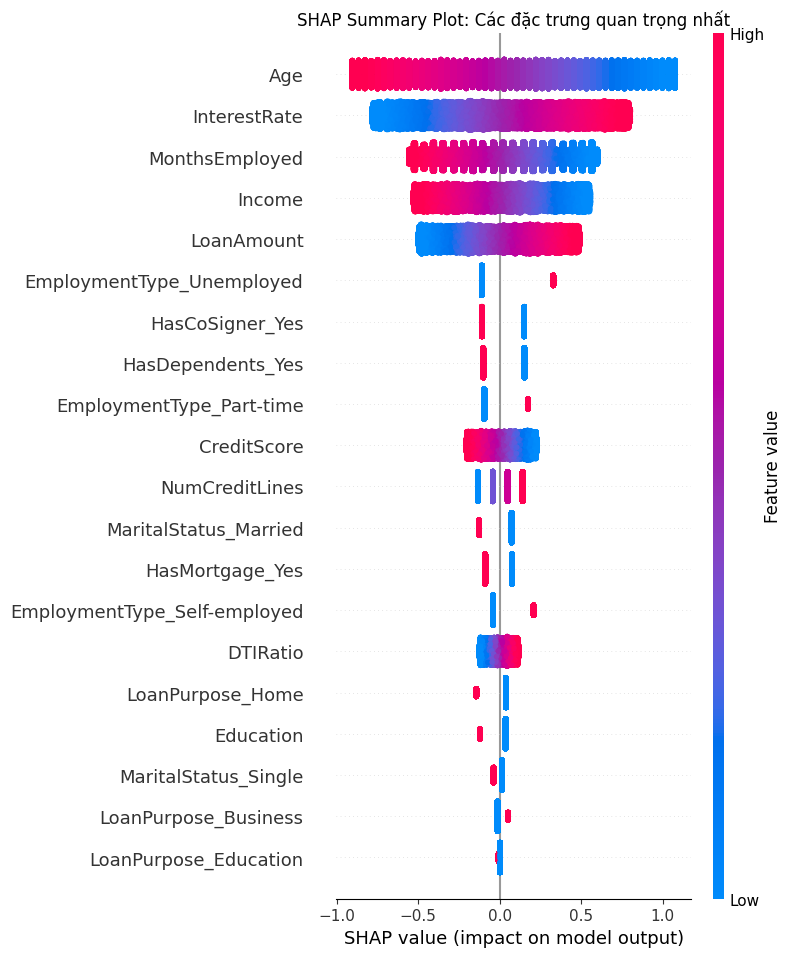

In [22]:
import shap
import matplotlib.pyplot as plt
import joblib
import pandas as pd

# 1. Load Model "Nhà vô địch" và Dữ liệu đã chuẩn hóa (Final Bundle)
X_train, X_test, y_train, y_test = load_data_bundle()

# Load model (Ví dụ XGBoost)
model_name = "Logistic_Regression"
model = load_best_model(model_name_keyword=model_name)

# 2. Khởi tạo SHAP Explainer
# SHAP có trình giải thích riêng cho các mô hình dạng cây (TreeExplainer) rất nhanh
explainer = get_shap_explainer(model=model, X_train=X_train)
shap_values = explainer.shap_values(X_test)

# 3. Trực quan hóa 1: Summary Plot (Toàn cảnh mô hình)
def plot_shap_summary(shap_values, features):
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, features, show=False)
    plt.title("SHAP Summary Plot: Các đặc trưng quan trọng nhất")
    plt.show()

# 4. Trực quan hóa 2: Waterfall Plot (Giải thích cho 1 khách hàng cụ thể)
def explain_single_prediction(explainer, shap_values, features, instance_index=0):
    """Giải thích tại sao khách hàng thứ 'instance_index' bị dự báo như vậy."""
    plt.figure()
    # Lấy giá trị kỳ vọng (base value)
    expected_value = explainer.expected_value
    
    shap.plots._waterfall_plot_legacy(expected_value, shap_values[instance_index], 
                                     features.iloc[instance_index], max_display=10)
    plt.show()

# --- THỰC THI ---
# Vẽ biểu đồ tổng quan
plot_shap_summary(shap_values, X_test)

In [23]:
import pandas as pd
import numpy as np

def export_shap_to_df(shap_values, features):
    """
    Chuyển đổi SHAP values thành DataFrame để dễ dàng quan sát và báo cáo.
    """
    # 1. Xử lý nếu shap_values là list (Trường hợp Logistic Regression)
    if isinstance(shap_values, list):
        # Lấy mảng cho Class 1 (Nợ xấu)
        shap_matrix = shap_values[1]
    else:
        shap_matrix = shap_values

    # 2. Tính giá trị tuyệt đối trung bình cho mỗi cột
    # Đây là chỉ số chuẩn để xếp hạng độ quan trọng của biến
    mean_shap = np.abs(shap_matrix).mean(axis=0)
    
    # 3. Tạo DataFrame kết quả
    importance_df = pd.DataFrame({
        'Feature': features.columns,
        'Mean_SHAP_Value': mean_shap
    })
    
    # Sắp xếp từ cao xuống thấp
    importance_df = importance_df.sort_values(by='Mean_SHAP_Value', ascending=False).reset_index(drop=True)
    
    return importance_df

# --- CÁCH CHẠY ---
shap_table = export_shap_to_df(shap_values, X_test)
print(shap_table.head(10)) # Hiển thị Top 10 biến

                     Feature  Mean_SHAP_Value
0                        Age         0.508254
1               InterestRate         0.396257
2             MonthsEmployed         0.290883
3                     Income         0.271741
4                 LoanAmount         0.248693
5  EmploymentType_Unemployed         0.164699
6            HasCoSigner_Yes         0.129507
7          HasDependents_Yes         0.126277
8   EmploymentType_Part-time         0.114393
9                CreditScore         0.108335


### MODEL: Logistic Regression (AUC: 0.7458)

### 1. "Xương sống" của rủi ro: Top 3 biến quyết định
* **Độ tuổi (Age) là số 1:** Đây là biến có quyền lực nhất. Mô hình đang phân loại rủi ro cực mạnh dựa trên nhóm tuổi (thường người trẻ hơn hoặc quá già sẽ có biến động rủi ro cao trong tập dữ liệu này).
* **Chi phí vay (Interest Rate):** Tác động lớn thứ 2. Lãi suất cao là rào cản trực tiếp khiến khách hàng mất khả năng thanh toán.
* **Sự ổn định (Months Employed):** Thâm niên làm việc quan trọng hơn cả mức thu nhập. Người làm việc lâu năm được mô hình tin tưởng hơn người lương cao nhưng mới nhảy việc.

### 2. Sự "thất thế" của Điểm tín dụng (Credit Score)
* **Bất thường:** `Credit Score` chỉ đứng thứ 10. Điều này cho thấy trong tập dữ liệu của bạn, lịch sử tín dụng quá khứ **không quan trọng bằng** tình trạng tài chính hiện tại (Thu nhập, Khoản vay) và nhân thân (Tuổi).

### 3. Tín hiệu từ các biến định tính (Categorical)
* **Thất nghiệp (Unemployed):** Có trọng số cảnh báo nợ xấu mạnh hơn nhiều so với việc làm bán thời gian.
* **Người bảo lãnh (Co-Signer):** Việc có người bảo lãnh có tác động giảm rủi ro tương đương với việc có người phụ thuộc (Dependents), nhưng cả hai đều chỉ là biến phụ trợ (Top 7-8).

### 4. Đánh giá kỹ thuật (Technical Verdict)
* **Mô hình Tuyến tính chiếm ưu thế:** Việc Logistic Regression thắng XGBoost chứng tỏ các biến số tác động đến nợ xấu theo tỷ lệ thuận/nghịch trực tiếp, ít có các mối quan hệ đan xen phức tạp (non-linear).
* **Độ nhạy (Recall 51%):** Mô hình đang ở mức "phòng ngự". Nó chấp nhận báo động nhầm nhiều (Precision thấp) để đảm bảo không bỏ sót quá nửa số con nợ xấu thực sự.



---